# Objetivo 2 — Reproducción de resultados y figuras para tesis
### Carga-o-entrena (SVM · Random Forest · XGBoost) + figuras PDF con la estética de `graficar_resultados.py`

**Tesista:** Jimy Alex Flores Araca   |   **Asesor:** Dr. Dennis Barrios Aranibar

Este notebook **no reentrena si ya existen los modelos guardados**: los carga y solo regenera resultados y figuras.
Si faltan, entrena de forma reproducible (misma semilla, mismo split, mismas features que el notebook de entrenamiento)
y los guarda.

**Qué produce, por cada modelo** (en subcarpetas `svm/`, `rf/`, `xgboost/` dentro de `RESULTS_DIR`):

- CSVs en el formato **exacto** que consume `graficar_resultados.py`:
  `accuracy_vs_snr.csv`, `confusion_global.csv`, `confusion_snr_<snr>.csv`, `class_metrics.csv`, `metrics_by_snr.csv`
  y `Combi0.csv` (solo XGBoost, ver nota).
- Figuras **PDF vectoriales** generadas con tu script `graficar_resultados.py` **reutilizado tal cual**
  (fuente serif, mismos tamaños, colormap azul, mismos nombres de archivo).

> **Convención de trazabilidad:** `# [REPORTADO]` (de la literatura, con cita), `# [NO REPORTADO]` (no especificado → elección
> propia justificada), `# [ADAPTACIÓN]` (implementación propia desde la descripción metodológica).

> **Nota honesta sobre `Combi0.csv` (curva por época).** Solo tiene sentido para modelos con entrenamiento iterativo.
> SVM y Random Forest **no** tienen curva de convergencia por época, así que **no** se les genera `Combi0.csv`
> (el grafador omite esa figura limpiamente). Para **XGBoost** sí se genera, usando las **rondas de boosting** como eje
> de iteración; esto requiere haber entrenado en esta sesión (un modelo ya guardado no conserva la traza de entrenamiento).


## 0. Configuración y reproducibilidad

In [ ]:
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Rutas en Drive ---
DATASET_PATH = '/content/drive/MyDrive/Sync GD/TESIS/Colab/Datasets/RML2016.10a_dict.pkl/RML2016.10a_dict.pkl'
# Carpeta donde el notebook de ENTRENAMIENTO dejó los modelos/objetos (.joblib / .json)
MODELS_DIR   = '/content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2'
# Carpeta donde ESTE notebook deja CSVs y figuras (puede ser la misma)
RESULTS_DIR  = '/content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2'

# --- Protocolo (debe coincidir con el del entrenamiento para reproducir el MISMO test) ---
TEST_SIZE = 0.50               # [REPORTADO] O'Shea 2016 / Rajendran 2018
STRATIFY_BY_MOD_SNR = True     # [ADAPTACIÓN] balance por (modulación, SNR)
SVM_TRAIN_SUBSAMPLE = 20000    # [DECISIÓN] viabilidad O(n^2) del SVM-RBF (solo si se entrena)

# Nombres de archivos de modelos (los que dejó el notebook de entrenamiento)
F_SCALER = 'scaler.joblib'
F_LE     = 'label_encoder.joblib'
F_RF     = 'modelo_rf.joblib'
F_SVM    = 'modelo_svm.joblib'
F_XGB    = 'modelo_xgb.json'

# Modelo -> (nombre legible, subcarpeta)
MODELOS = {'svm': 'SVM-RBF', 'rf': 'RandomForest-150', 'xgboost': 'XGBoost'}
print("Semilla:", SEED, "| dataset:", os.path.basename(DATASET_PATH))

Semilla: 42 | dataset: RML2016.10a_dict.pkl


## 1. Instalación e imports

`xgboost` para cargar/entrenar el modelo; `pymupdf` solo para previsualizar los PDF dentro de Colab.

In [ ]:
!pip -q install --upgrade xgboost pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 26.6 MB/s eta 0:00:00


In [ ]:
import pickle, csv, glob, subprocess
from time import time

import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier
import sklearn, xgboost
print("scikit-learn", sklearn.__version__, "| xgboost", xgboost.__version__)

scikit-learn 1.6.1 | xgboost 3.2.0


## 2. Montaje de Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Reutilizar `graficar_resultados.py` (estética idéntica)

Para que las figuras sean **exactamente** las de tu script, lo escribimos en el entorno de Colab **verbatim**
con `%%writefile` y luego lo invocamos por modelo. Así la estética (serif, tamaños, colormap azul, nombres de
salida) es la tuya, sin reimplementarla.

In [ ]:
%%writefile graficar_resultados.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
graficar_resultados.py
=====================================================================
Genera figuras en PDF (vectorial, listas para LaTeX) a partir de los
CSV de resultados de la red IVQ-Net en la tarea de Clasificacion
Automatica de Modulacion (AMC).

Lee de la carpeta de entrada:
  - confusion_global.csv            -> matriz de confusion global
  - confusion_snr_<snr>.csv         -> una matriz por nivel de SNR
                                       (m20 = -20 dB ... 18 = +18 dB)
  - accuracy_vs_snr.csv             -> curva accuracy vs SNR
  - class_metrics.csv               -> precision/recall/F1 por clase
  - metrics_by_snr.csv              -> metricas macro por SNR
  - Combi0.csv                      -> error/accuracy por epoca

Produce en la carpeta de salida (PDF):
  - confusion_global.pdf
  - confusion_por_snr/confusion_snr_<snr>.pdf   (una por nivel)
  - confusion_grid_snr.pdf          -> mosaico con todas las SNR
  - accuracy_vs_snr.pdf
  - metricas_por_clase.pdf          -> barras precision/recall/F1
  - f1_vs_snr.pdf                   -> precision/recall/F1/acc macro vs SNR
  - curva_error_por_epoca.pdf       -> error y accuracy vs epoca
  - curva_accuracy_por_epoca.pdf

Uso:
  python3 graficar_resultados.py --in . --out figuras_pdf

Requisitos: numpy, matplotlib   (pip install numpy matplotlib)
=====================================================================
"""

import argparse
import csv
import glob
import os
import re
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "figure.dpi": 150,
})


# ---------------------------------------------------------------------------
# Utilidades de lectura (manejan \r\n de Windows y separador coma)
# ---------------------------------------------------------------------------
def read_confusion(path):
    """Lee una matriz de confusion. Devuelve (labels, M [int])."""
    with open(path, newline="") as f:
        rows = list(csv.reader(f))
    rows = [r for r in rows if r and any(c.strip() for c in r)]
    header = rows[0]
    labels = [h.strip() for h in header[1:]]
    M = []
    for r in rows[1:]:
        M.append([int(float(v)) for v in r[1:]])
    return labels, np.array(M, dtype=np.int64)


def read_kv_csv(path):
    """Lee un CSV con cabecera y devuelve dict de columnas (listas de str)."""
    with open(path, newline="") as f:
        rows = list(csv.reader(f))
    rows = [r for r in rows if r and any(c.strip() for c in r)]
    header = [h.strip() for h in rows[0]]
    cols = {h: [] for h in header}
    for r in rows[1:]:
        for h, v in zip(header, r):
            cols[h].append(v.strip())
    return cols


def snr_from_filename(path):
    """confusion_snr_m20.csv -> -20 ; confusion_snr_18.csv -> 18."""
    name = os.path.basename(path)
    m = re.search(r"confusion_snr_(m?)(\d+)\.csv", name)
    if not m:
        return None
    sign = -1 if m.group(1) == "m" else 1
    return sign * int(m.group(2))


# ---------------------------------------------------------------------------
# Graficado de matriz de confusion
# ---------------------------------------------------------------------------
def plot_confusion(labels, M, title, out_path, normalize=True):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(7.2, 6.2))

    if normalize:
        row_sums = M.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            data = np.where(row_sums > 0, M / row_sums, 0.0)
        fmt = lambda v: f"{v*100:.0f}"   # porcentaje por fila
        cbar_label = "Proporcion por fila (recall por celda)"
    else:
        data = M.astype(float)
        fmt = lambda v: f"{int(v)}"
        cbar_label = "Conteo"

    cmap = LinearSegmentedColormap.from_list("blues", ["#f7fbff", "#08306b"])
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=data.max() if data.max() > 0 else 1)

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Clase real")
    ax.set_title(title)

    # Anotaciones (solo si la rejilla no es demasiado densa)
    thresh = data.max() / 2.0 if data.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            val = data[i, j]
            if normalize and val < 0.005:
                continue
            ax.text(j, i, fmt(val), ha="center", va="center",
                    color="white" if val > thresh else "black", fontsize=6.5)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=8)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)


def plot_confusion_grid(snr_files, out_path):
    """Mosaico compacto: una mini matriz (normalizada) por SNR."""
    snr_files = sorted(snr_files, key=lambda kv: kv[0])
    n = len(snr_files)
    if n == 0:
        return
    cols = 5
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 2.4 * rows))
    axes = np.array(axes).reshape(-1)
    cmap = LinearSegmentedColormap.from_list("blues", ["#f7fbff", "#08306b"])

    for ax in axes[n:]:
        ax.axis("off")

    for ax, (snr, labels, M) in zip(axes, snr_files):
        row_sums = M.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            data = np.where(row_sums > 0, M / row_sums, 0.0)
        ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
        acc = np.trace(M) / M.sum() if M.sum() > 0 else 0
        ax.set_title(f"SNR={snr} dB  (acc={acc*100:.0f}%)", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Matrices de confusion normalizadas por nivel de SNR",
                 fontsize=12, y=1.0)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
# Curvas
# ---------------------------------------------------------------------------
def plot_accuracy_vs_snr(path, out_path):
    cols = read_kv_csv(path)
    snr = np.array([int(float(s)) for s in cols["snr"]])
    acc = np.array([float(a) for a in cols["accuracy"]]) * 100
    order = np.argsort(snr)
    snr, acc = snr[order], acc[order]

    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    ax.plot(snr, acc, "o-", color="#08519c", lw=1.8, markersize=4)
    ax.axhline(100 / 11, color="gray", ls="--", lw=1)
    ax.text(snr.min(), 100 / 11 + 1.5, "azar (1/11 = 9.1%)",
            fontsize=8, color="gray")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Exactitud frente al SNR (IVQ-Net)")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, max(100, acc.max() + 5))
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)


def plot_class_metrics(path, out_path):
    cols = read_kv_csv(path)
    classes, prec, rec, f1 = [], [], [], []
    for c, p, r, f in zip(cols["class"], cols["precision"],
                          cols["recall"], cols["f1"]):
        if c in ("MACRO", "ACCURACY"):
            continue
        classes.append(c)
        prec.append(float(p)); rec.append(float(r)); f1.append(float(f))

    x = np.arange(len(classes))
    w = 0.26
    fig, ax = plt.subplots(figsize=(8.2, 4.2))
    ax.bar(x - w, prec, w, label="Precision", color="#6baed6")
    ax.bar(x,      rec,  w, label="Recall",    color="#fd8d3c")
    ax.bar(x + w,  f1,   w, label="F1-score",  color="#74c476")
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Valor")
    ax.set_ylim(0, 1)
    ax.set_title("Metricas por clase (IVQ-Net)")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)


def plot_metrics_by_snr(path, out_path):
    cols = read_kv_csv(path)
    snr = np.array([int(float(s)) for s in cols["snr"]])
    order = np.argsort(snr)
    snr = snr[order]

    def col(name):
        return np.array([float(v) for v in cols[name]])[order] * 100

    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    ax.plot(snr, col("precision_macro"), "o-", label="Precision (macro)", lw=1.5, ms=3)
    ax.plot(snr, col("recall_macro"),    "s-", label="Recall (macro)",    lw=1.5, ms=3)
    ax.plot(snr, col("f1_macro"),        "^-", label="F1 (macro)",        lw=1.5, ms=3)
    ax.plot(snr, col("accuracy"),        "d-", label="Accuracy",          lw=1.5, ms=3)
    ax.axhline(100 / 11, color="gray", ls="--", lw=1)
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Valor (%)")
    ax.set_title("Metricas macro frente al SNR (IVQ-Net)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)


def plot_epoch_curves(path, out_err, out_acc):
    """Combi0.csv: epoch, temp, errTrain, desvTrain, errTest, desvTest."""
    epochs, et, dt, ev, dv = [], [], [], [], []
    with open(path, newline="") as f:
        for r in csv.reader(f):
            if not r or len(r) < 6:
                continue
            try:
                epochs.append(int(float(r[0])))
                et.append(float(r[2])); dt.append(float(r[3]))
                ev.append(float(r[4])); dv.append(float(r[5]))
            except ValueError:
                continue
    epochs = np.array(epochs)
    et, dt, ev, dv = map(np.array, (et, dt, ev, dv))

    # Curva de error
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    ax.plot(epochs, et, "-", color="#c0392b", lw=1.5, label="Error train")
    ax.plot(epochs, ev, "-", color="#2471a3", lw=1.5, label="Error test")
    if dt.any():
        ax.fill_between(epochs, et - dt, et + dt, color="#c0392b", alpha=0.15)
    if dv.any():
        ax.fill_between(epochs, ev - dv, ev + dv, color="#2471a3", alpha=0.15)
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Error de clasificacion (%)")
    ax.set_title("Error por epoca (IVQ-Net)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_err, bbox_inches="tight")
    plt.close(fig)

    # Curva de accuracy (= 100 - error)
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    ax.plot(epochs, 100 - et, "-", color="#c0392b", lw=1.5, label="Accuracy train")
    ax.plot(epochs, 100 - ev, "-", color="#2471a3", lw=1.5, label="Accuracy test")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy por epoca (IVQ-Net)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_acc, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
# main
# ---------------------------------------------------------------------------
def main():
    ap = argparse.ArgumentParser(description="Grafica resultados AMC a PDF.")
    ap.add_argument("--in", dest="indir", default=".", help="carpeta con los CSV")
    ap.add_argument("--out", dest="outdir", default="figuras_pdf", help="carpeta de salida")
    ap.add_argument("--counts", action="store_true",
                    help="matrices con conteos en vez de normalizadas por fila")
    args = ap.parse_args()

    os.makedirs(args.outdir, exist_ok=True)
    snr_dir = os.path.join(args.outdir, "confusion_por_snr")
    os.makedirs(snr_dir, exist_ok=True)

    normalize = not args.counts

    def has(name):
        return os.path.isfile(os.path.join(args.indir, name))

    # 1. Matriz de confusion global
    if has("confusion_global.csv"):
        labels, M = read_confusion(os.path.join(args.indir, "confusion_global.csv"))
        acc = np.trace(M) / M.sum() * 100
        plot_confusion(labels, M,
                       f"Matriz de confusion global (acc={acc:.1f}%)",
                       os.path.join(args.outdir, "confusion_global.pdf"),
                       normalize=normalize)
        print(f"[ok] confusion_global.pdf   (accuracy global = {acc:.2f}%)")

    # 2. Matrices por SNR (individuales + mosaico)
    snr_paths = glob.glob(os.path.join(args.indir, "confusion_snr_*.csv"))
    grid_data = []
    for p in snr_paths:
        snr = snr_from_filename(p)
        if snr is None:
            continue
        labels, M = read_confusion(p)
        acc = np.trace(M) / M.sum() * 100 if M.sum() > 0 else 0
        tag = f"m{abs(snr)}" if snr < 0 else f"{snr}"
        plot_confusion(labels, M,
                       f"Confusion a SNR = {snr} dB  (acc={acc:.1f}%)",
                       os.path.join(snr_dir, f"confusion_snr_{tag}.pdf"),
                       normalize=normalize)
        grid_data.append((snr, labels, M))
    if snr_paths:
        print(f"[ok] {len(grid_data)} matrices por SNR en {snr_dir}/")
        plot_confusion_grid(grid_data, os.path.join(args.outdir, "confusion_grid_snr.pdf"))
        print("[ok] confusion_grid_snr.pdf   (mosaico con todas las SNR)")

    # 3. Accuracy vs SNR
    if has("accuracy_vs_snr.csv"):
        plot_accuracy_vs_snr(os.path.join(args.indir, "accuracy_vs_snr.csv"),
                             os.path.join(args.outdir, "accuracy_vs_snr.pdf"))
        print("[ok] accuracy_vs_snr.pdf")

    # 4. Metricas por clase
    if has("class_metrics.csv"):
        plot_class_metrics(os.path.join(args.indir, "class_metrics.csv"),
                           os.path.join(args.outdir, "metricas_por_clase.pdf"))
        print("[ok] metricas_por_clase.pdf")

    # 5. Metricas macro vs SNR
    if has("metrics_by_snr.csv"):
        plot_metrics_by_snr(os.path.join(args.indir, "metrics_by_snr.csv"),
                            os.path.join(args.outdir, "f1_vs_snr.pdf"))
        print("[ok] f1_vs_snr.pdf")

    # 6. Curvas por epoca
    if has("Combi0.csv"):
        plot_epoch_curves(os.path.join(args.indir, "Combi0.csv"),
                          os.path.join(args.outdir, "curva_error_por_epoca.pdf"),
                          os.path.join(args.outdir, "curva_accuracy_por_epoca.pdf"))
        print("[ok] curva_error_por_epoca.pdf / curva_accuracy_por_epoca.pdf")

    print(f"\nListo. Figuras PDF en: {os.path.abspath(args.outdir)}")


if __name__ == "__main__":
    main()

Writing graficar_resultados.py


## 4. Extractor de características (idéntico al de entrenamiento)

> **Crítico para reproducibilidad:** el `scaler.joblib` y los modelos guardados esperan **estas mismas 16
> características en este mismo orden**. No las cambies aquí o las predicciones serán inválidas.
>
> **[ADAPTACIÓN]** Cumulantes hasta 4.º orden (Swami & Sadler) + estadísticos de amplitud/fase/frecuencia
> instantánea (familia Azzouz–Nandi).

In [ ]:
def extract_features(iq):
    """16 features HOC + estadísticos a partir de un ejemplo IQ (2,128). IDÉNTICO al entrenamiento."""
    I = iq[0].astype(np.float64); Q = iq[1].astype(np.float64)
    x = I + 1j * Q
    p = np.sqrt(np.mean(np.abs(x)**2)) + 1e-12
    xn = x / p
    M20 = np.mean(xn**2); M21 = np.mean(np.abs(xn)**2)
    M40 = np.mean(xn**4); M41 = np.mean(xn**3 * np.conj(xn)); M42 = np.mean(np.abs(xn)**4)
    C20 = M20; C21 = M21
    C40 = M40 - 3 * M20**2
    C41 = M41 - 3 * M20 * M21
    C42 = M42 - np.abs(M20)**2 - 2 * M21**2
    d = C21**2 + 1e-12
    C40n, C41n, C42n = C40/d, C41/d, C42/d
    A = np.abs(x); Acn = A/(np.mean(A) + 1e-12) - 1.0
    phi = np.unwrap(np.angle(x)); fi = np.diff(phi)
    def kurt(v):
        v = v - np.mean(v); return np.mean(v**4)/(np.var(v)**2 + 1e-12)
    return np.array([
        np.real(C20), np.imag(C20), C21,
        np.abs(C40n), np.abs(C41n), np.abs(C42n),
        np.real(C40n), np.imag(C40n),
        np.mean(A), np.std(A),
        np.std(Acn), kurt(Acn),
        np.std(phi), np.std(np.abs(phi - np.mean(phi))),
        np.std(fi), kurt(fi),
    ], dtype=np.float64)

FEATURE_NAMES = ['ReC20','ImC20','C21','absC40n','absC41n','absC42n','ReC40n','ImC40n',
                 'mean_A','std_A','std_Acn','kurt_Acn','std_phi','std_absphi','std_fi','kurt_fi']
print("Nº de características:", len(FEATURE_NAMES))

Nº de características: 16


## 5. Carga y verificación del dataset

In [ ]:
assert os.path.exists(DATASET_PATH), "No se encontró el dataset:\n%s" % DATASET_PATH
with open(DATASET_PATH, 'rb') as f:
    dataset = pickle.load(f, encoding='latin1')
keys = list(dataset.keys())
print("Pares (mod, snr):", len(keys),
      "| modulaciones:", len({k[0] for k in keys}),
      "| SNRs:", sorted({k[1] for k in keys}))

Pares (mod, snr): 220 | modulaciones: 11 | SNRs: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


## 6. Extracción de X, y, SNR → características → split reproducible

El split se reproduce con la **misma semilla y estratificación** que el entrenamiento; así, al reusar modelos,
se evalúa exactamente sobre el **mismo conjunto de test**.

In [ ]:
X_iq, y_mod, y_snr = [], [], []
for (mod, snr), block in dataset.items():
    block = np.asarray(block, dtype=np.float32)
    for s in block:
        X_iq.append(s); y_mod.append(mod); y_snr.append(snr)
X_iq  = np.asarray(X_iq, dtype=np.float32)
y_mod = np.asarray(y_mod)
y_snr = np.asarray(y_snr, dtype=int)

t0 = time()
X_feat = np.nan_to_num(np.vstack([extract_features(s) for s in X_iq]))
print("X_feat:", X_feat.shape, "| extracción:", round(time()-t0,1), "s")

strat = (np.array([f"{m}|{s}" for m, s in zip(y_mod, y_snr)])
         if STRATIFY_BY_MOD_SNR else None)
idx = np.arange(len(y_mod))
idx_tr, idx_te = train_test_split(idx, test_size=TEST_SIZE, random_state=SEED, stratify=strat)
print("Train:", len(idx_tr), "| Test:", len(idx_te))

X_feat: (220000, 16) | extracción: 123.3 s
Train: 110000 | Test: 110000


## 7. Cargar modelos guardados o entrenar de forma reproducible

**Regla:** si existen los 5 archivos (`scaler`, `label_encoder`, `rf`, `svm`, `xgb`) → se cargan y **no se reentrena**.
Si falta alguno → se entrena todo con la configuración reproducible y se guarda.

> Hiperparámetros: RF `n_estimators=150` **[REPORTADO]** (Rajendran 2018); SVM `C=10, gamma='scale'` y XGBoost
> (300 árboles, depth 6, lr 0.1) **[NO REPORTADO]** → elecciones razonables justificadas en el notebook de entrenamiento.

In [ ]:
paths = {
    'scaler': os.path.join(MODELS_DIR, F_SCALER),
    'le':     os.path.join(MODELS_DIR, F_LE),
    'rf':     os.path.join(MODELS_DIR, F_RF),
    'svm':    os.path.join(MODELS_DIR, F_SVM),
    'xgb':    os.path.join(MODELS_DIR, F_XGB),
}
MODELS_EXIST = all(os.path.exists(p) for p in paths.values())
print("Modelos guardados presentes:", MODELS_EXIST)
for k, p in paths.items():
    print(f"  [{'x' if os.path.exists(p) else ' '}] {k}: {p}")

combi0_rows = None   # se llena solo si se entrena XGBoost en esta sesión

if MODELS_EXIST:
    print("\n>>> Reutilizando modelos. NO se reentrena.")
    scaler = joblib.load(paths['scaler'])
    le     = joblib.load(paths['le'])
    rf     = joblib.load(paths['rf'])
    svm    = joblib.load(paths['svm'])
    xgb    = XGBClassifier(); xgb.load_model(paths['xgb'])
    TRAINED = False
else:
    print("\n>>> Falta al menos un modelo. Entrenamiento reproducible.")
    le     = LabelEncoder().fit(y_mod)
    scaler = StandardScaler().fit(X_feat[idx_tr])
    TRAINED = True

# Etiquetas, test escalado y SNR de test (común a ambos caminos)
classes = list(le.classes_)
y   = le.transform(y_mod)
ytr = y[idx_tr]; yte = y[idx_te]
snr_te = y_snr[idx_te]
Xte = scaler.transform(X_feat[idx_te])

if TRAINED:
    Xtr = scaler.transform(X_feat[idx_tr])

    # --- SVM sobre subconjunto estratificado (viabilidad) ---
    if SVM_TRAIN_SUBSAMPLE and len(ytr) > SVM_TRAIN_SUBSAMPLE:
        _, sub = train_test_split(np.arange(len(ytr)),
                                  test_size=SVM_TRAIN_SUBSAMPLE/len(ytr),
                                  random_state=SEED, stratify=ytr)
        Xs, ys = Xtr[sub], ytr[sub]
    else:
        Xs, ys = Xtr, ytr
    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED).fit(Xs, ys)   # [NO REPORTADO]

    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=SEED).fit(Xtr, ytr)  # [REPORTADO]

    # --- XGBoost (captura curva de boosting -> Combi0) ---
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        subsample=0.9, colsample_bytree=0.9,
                        objective='multi:softprob', num_class=len(classes),
                        tree_method='hist', eval_metric='merror',
                        n_jobs=-1, random_state=SEED)
    xgb.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xte, yte)], verbose=False)
    ev = xgb.evals_result()
    errTr = np.array(ev['validation_0']['merror']) * 100.0
    errTe = np.array(ev['validation_1']['merror']) * 100.0
    combi0_rows = [(i+1, 0.0, float(errTr[i]), 0.0, float(errTe[i]), 0.0)
                   for i in range(len(errTr))]

    # --- Guardar todo ---
    os.makedirs(MODELS_DIR, exist_ok=True)
    joblib.dump(scaler, paths['scaler']); joblib.dump(le, paths['le'])
    joblib.dump(rf, paths['rf']);         joblib.dump(svm, paths['svm'])
    xgb.save_model(paths['xgb'])
    print("Modelos entrenados y guardados en:", MODELS_DIR)

print("Clases:", classes)

Modelos guardados presentes: True
  [x] scaler: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/scaler.joblib
  [x] le: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/label_encoder.joblib
  [x] rf: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/modelo_rf.joblib
  [x] svm: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/modelo_svm.joblib
  [x] xgb: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/modelo_xgb.json

>>> Reutilizando modelos. NO se reentrena.
Clases: [np.str_('8PSK'), np.str_('AM-DSB'), np.str_('AM-SSB'), np.str_('BPSK'), np.str_('CPFSK'), np.str_('GFSK'), np.str_('PAM4'), np.str_('QAM16'), np.str_('QAM64'), np.str_('QPSK'), np.str_('WBFM')]


## 8. Predicciones sobre el conjunto de test

In [ ]:
preds = {
    'svm':     svm.predict(Xte),
    'rf':      rf.predict(Xte),
    'xgboost': xgb.predict(Xte),
}
for k, p in preds.items():
    print(f"{MODELOS[k]:18s} accuracy global = {accuracy_score(yte, p):.4f}")

SVM-RBF            accuracy global = 0.4885
RandomForest-150   accuracy global = 0.5060
XGBoost            accuracy global = 0.5117


## 9. Reconstrucción de los CSV (formato exacto del grafador)

Funciones que escriben cada CSV **tal como `graficar_resultados.py` los lee**: matrices de confusión en **conteos
enteros**, métricas en **fracción [0,1]**, y `Combi0.csv` con el **error en %**.

In [ ]:
def w_confusion(path, ytrue, ypred):
    M = confusion_matrix(ytrue, ypred, labels=range(len(classes)))
    with open(path, 'w', newline='') as f:
        wr = csv.writer(f)
        wr.writerow(['label'] + classes)               # header[0] lo ignora el grafador
        for i, lab in enumerate(classes):
            wr.writerow([lab] + [int(v) for v in M[i]]) # conteos enteros

def w_accuracy_vs_snr(path, ytrue, ypred, snr_arr):
    with open(path, 'w', newline='') as f:
        wr = csv.writer(f); wr.writerow(['snr', 'accuracy'])
        for s in sorted(np.unique(snr_arr)):
            m = snr_arr == s
            wr.writerow([int(s), round(accuracy_score(ytrue[m], ypred[m]), 6)])  # fracción

def w_class_metrics(path, ytrue, ypred):
    rep = classification_report(ytrue, ypred, target_names=classes,
                                output_dict=True, zero_division=0)
    with open(path, 'w', newline='') as f:
        wr = csv.writer(f); wr.writerow(['class', 'precision', 'recall', 'f1'])
        for c in classes:
            d = rep[c]
            wr.writerow([c, round(d['precision'],6), round(d['recall'],6), round(d['f1-score'],6)])
        m = rep['macro avg']
        wr.writerow(['MACRO', round(m['precision'],6), round(m['recall'],6), round(m['f1-score'],6)])
        a = rep['accuracy']
        wr.writerow(['ACCURACY', round(a,6), round(a,6), round(a,6)])

def w_metrics_by_snr(path, ytrue, ypred, snr_arr):
    with open(path, 'w', newline='') as f:
        wr = csv.writer(f)
        wr.writerow(['snr', 'precision_macro', 'recall_macro', 'f1_macro', 'accuracy'])
        for s in sorted(np.unique(snr_arr)):
            m = snr_arr == s; yt, yp = ytrue[m], ypred[m]
            wr.writerow([int(s),
                         round(precision_score(yt, yp, average='macro', zero_division=0), 6),
                         round(recall_score(yt, yp, average='macro', zero_division=0), 6),
                         round(f1_score(yt, yp, average='macro', zero_division=0), 6),
                         round(accuracy_score(yt, yp), 6)])

def w_combi0(path, rows):
    # epoch, temp, errTrain%, desvTrain, errTest%, desvTest   (sin cabecera)
    with open(path, 'w', newline='') as f:
        wr = csv.writer(f)
        for r in rows:
            wr.writerow(r)
print("Escritores de CSV listos.")

Escritores de CSV listos.


### 9.1 Generar los CSV por modelo

In [ ]:
csv_dirs = {}
for key, nombre in MODELOS.items():
    cdir = os.path.join(RESULTS_DIR, key, 'csv')
    os.makedirs(cdir, exist_ok=True)
    csv_dirs[key] = cdir
    p = preds[key]

    w_confusion(os.path.join(cdir, 'confusion_global.csv'), yte, p)
    for s in sorted(np.unique(snr_te)):
        m = snr_te == s
        tag = f"m{abs(int(s))}" if s < 0 else f"{int(s)}"
        w_confusion(os.path.join(cdir, f'confusion_snr_{tag}.csv'), yte[m], p[m])
    w_accuracy_vs_snr(os.path.join(cdir, 'accuracy_vs_snr.csv'), yte, p, snr_te)
    w_class_metrics(os.path.join(cdir, 'class_metrics.csv'), yte, p)
    w_metrics_by_snr(os.path.join(cdir, 'metrics_by_snr.csv'), yte, p, snr_te)

    # Combi0 solo para XGBoost y solo si se entrenó en esta sesión
    if key == 'xgboost' and combi0_rows is not None:
        w_combi0(os.path.join(cdir, 'Combi0.csv'), combi0_rows)
        print("  Combi0.csv generado (curva de boosting de XGBoost).")
    elif key == 'xgboost':
        print("  Combi0.csv: no se regenera al reusar modelo guardado (requiere entrenar).")

    print(f"[{nombre}] CSVs en {cdir}")

[SVM-RBF] CSVs en /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/svm/csv
[RandomForest-150] CSVs en /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/rf/csv
  Combi0.csv: no se regenera al reusar modelo guardado (requiere entrenar).
[XGBoost] CSVs en /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/xgboost/csv


## 10. Figuras PDF con tu grafador (por modelo)

Se invoca `graficar_resultados.py` **sin modificar** una vez por modelo. Usamos `subprocess` con argumentos en
lista para que las **rutas con espacios** (`Sync GD`) se manejen bien.

In [ ]:
pdf_dirs = {}
for key, nombre in MODELOS.items():
    cdir = csv_dirs[key]
    pdir = os.path.join(RESULTS_DIR, key, 'figuras_pdf')
    os.makedirs(pdir, exist_ok=True)
    pdf_dirs[key] = pdir
    r = subprocess.run(['python3', 'graficar_resultados.py', '--in', cdir, '--out', pdir],
                       capture_output=True, text=True)
    print(f"=== {nombre} (rc={r.returncode}) ===")
    print(r.stdout.strip())
    if r.returncode != 0:
        print("STDERR:", r.stderr[-800:])

=== SVM-RBF (rc=0) ===
[ok] confusion_global.pdf   (accuracy global = 48.85%)
[ok] 20 matrices por SNR en /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/svm/figuras_pdf/confusion_por_snr/
[ok] confusion_grid_snr.pdf   (mosaico con todas las SNR)
[ok] accuracy_vs_snr.pdf
[ok] metricas_por_clase.pdf
[ok] f1_vs_snr.pdf

Listo. Figuras PDF en: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/svm/figuras_pdf
=== RandomForest-150 (rc=0) ===
[ok] confusion_global.pdf   (accuracy global = 50.60%)
[ok] 20 matrices por SNR en /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/rf/figuras_pdf/confusion_por_snr/
[ok] confusion_grid_snr.pdf   (mosaico con todas las SNR)
[ok] accuracy_vs_snr.pdf
[ok] metricas_por_clase.pdf
[ok] f1_vs_snr.pdf

Listo. Figuras PDF en: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/rf/figuras_pdf
=== XGBoost (rc=0) ===
[ok] confusion_global.pdf   (accuracy global = 51.17%)
[ok] 20 matrices por SNR en /content/

## 11. Guardado de resultados

Todo queda bajo `RESULTS_DIR` en subcarpetas por modelo (`<modelo>/csv` y `<modelo>/figuras_pdf`).
Se escribe además un resumen comparativo `resumen_global.csv`.

In [ ]:
import csv as _csv
resumen = os.path.join(RESULTS_DIR, 'resumen_global.csv')
with open(resumen, 'w', newline='') as f:
    wr = _csv.writer(f)
    wr.writerow(['modelo', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])
    for key, nombre in MODELOS.items():
        p = preds[key]
        wr.writerow([nombre,
                     round(accuracy_score(yte, p), 6),
                     round(precision_score(yte, p, average='macro', zero_division=0), 6),
                     round(recall_score(yte, p, average='macro', zero_division=0), 6),
                     round(f1_score(yte, p, average='macro', zero_division=0), 6)])
print("Resumen global ->", resumen)

print("\nÁrbol de resultados:")
for key in MODELOS:
    base = os.path.join(RESULTS_DIR, key)
    for sub in ('csv', 'figuras_pdf'):
        d = os.path.join(base, sub)
        if os.path.isdir(d):
            print(f"  {key}/{sub}: {len(os.listdir(d))} archivos")

Resumen global -> /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2/resumen_global.csv

Árbol de resultados:
  svm/csv: 24 archivos
  svm/figuras_pdf: 6 archivos
  rf/csv: 24 archivos
  rf/figuras_pdf: 6 archivos
  xgboost/csv: 24 archivos
  xgboost/figuras_pdf: 6 archivos


## 12. Previsualizar los PDF generados en Colab

Renderiza la primera página de cada PDF principal con PyMuPDF. (Los PDF siguen siendo vectoriales en disco;
esto es solo una vista rápida.)

SVM-RBF
accuracy_vs_snr.pdf


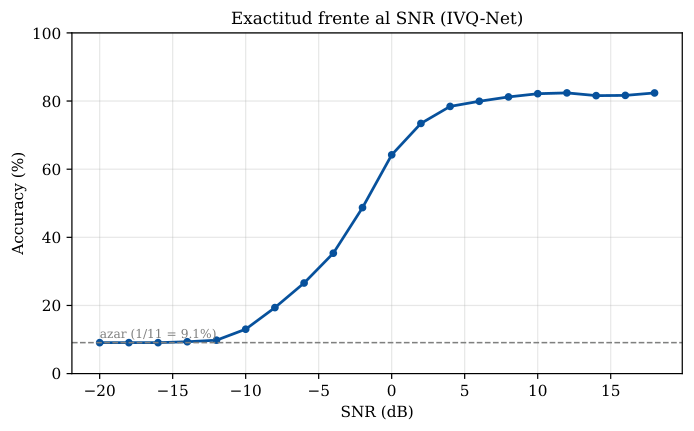

confusion_global.pdf


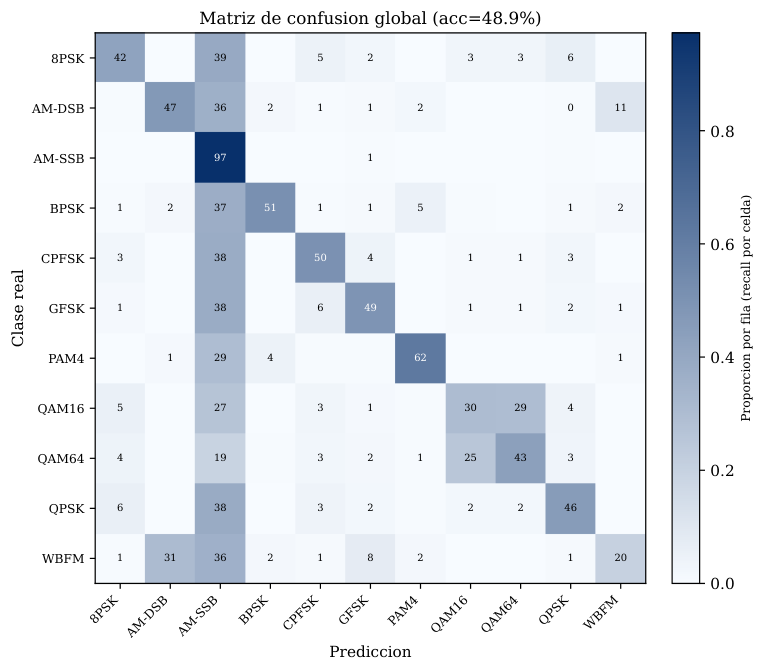

confusion_grid_snr.pdf


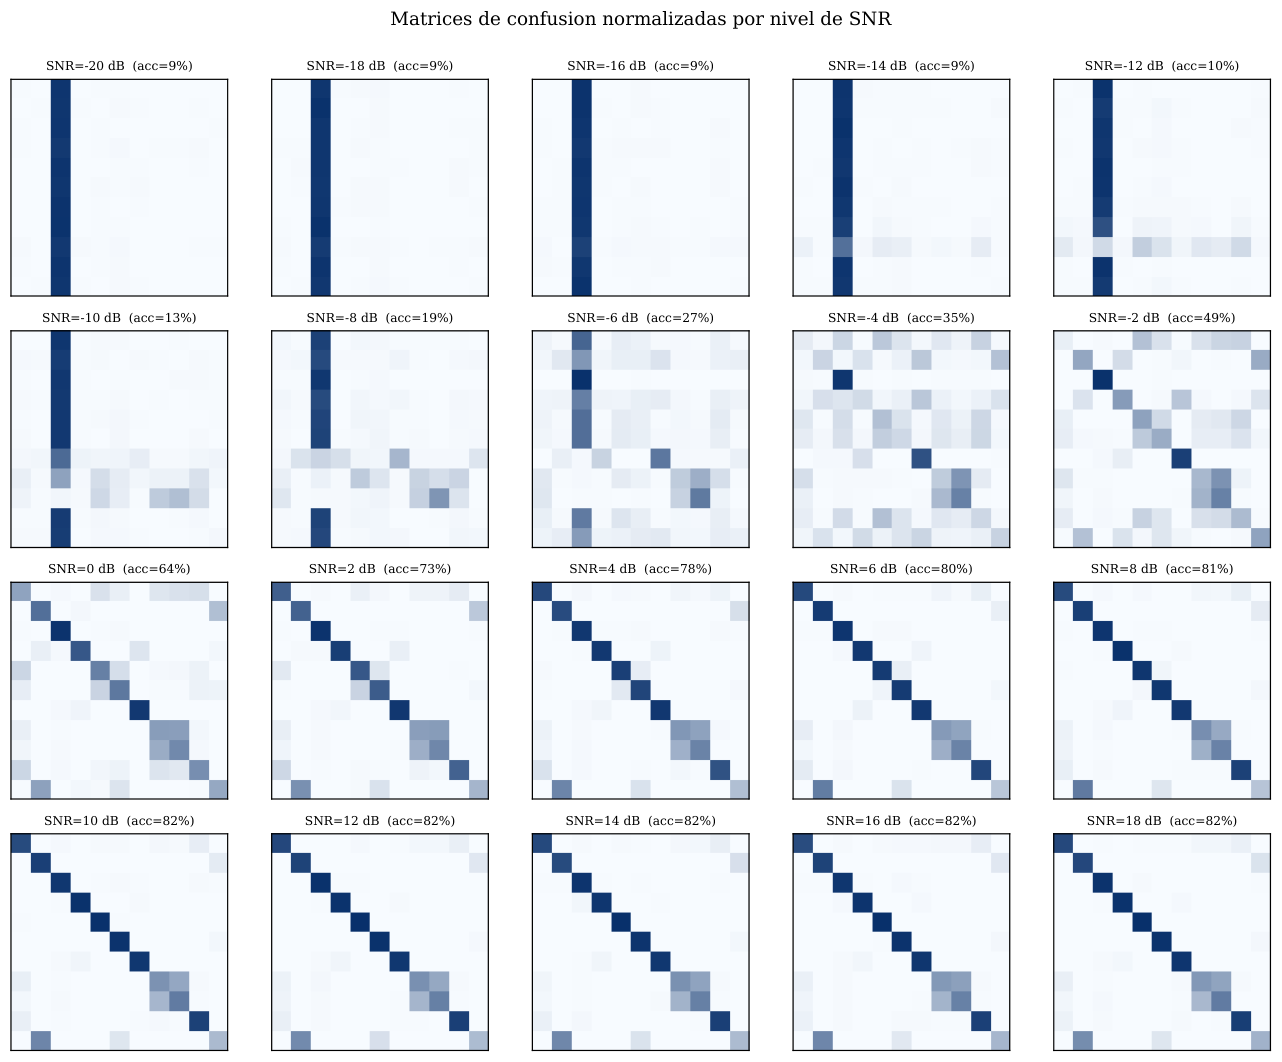

metricas_por_clase.pdf


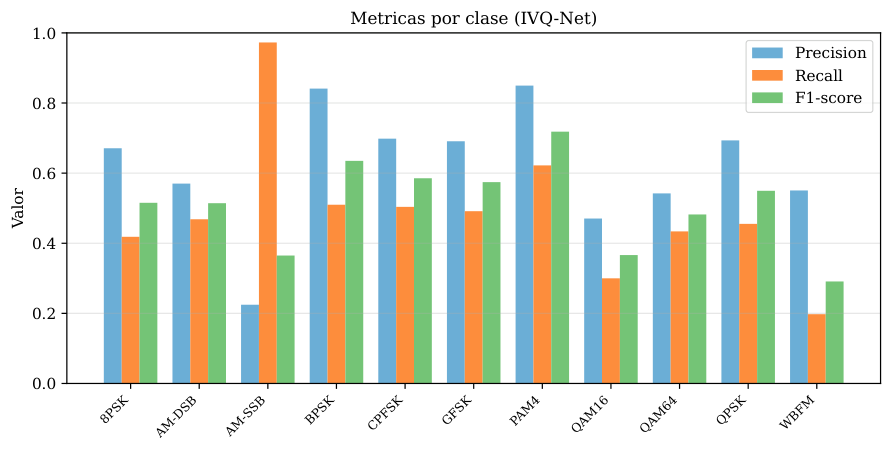

f1_vs_snr.pdf


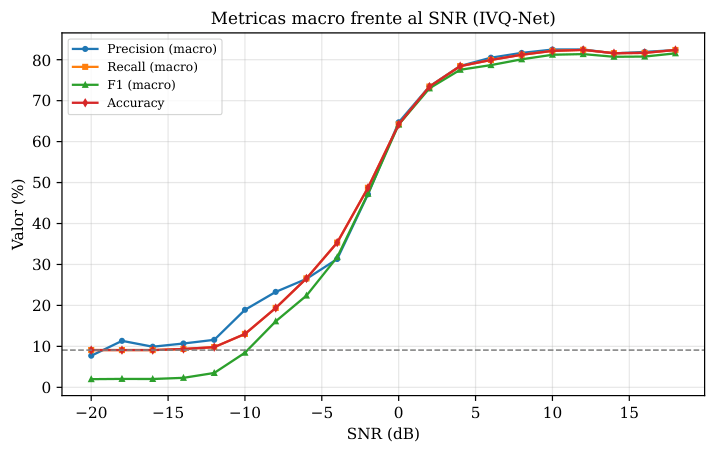

RandomForest-150
accuracy_vs_snr.pdf


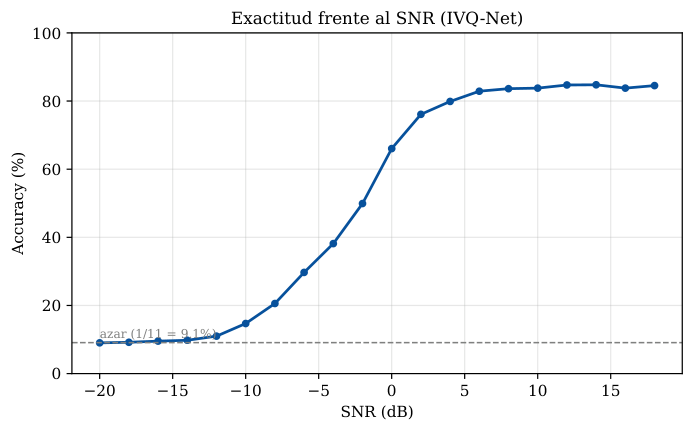

confusion_global.pdf


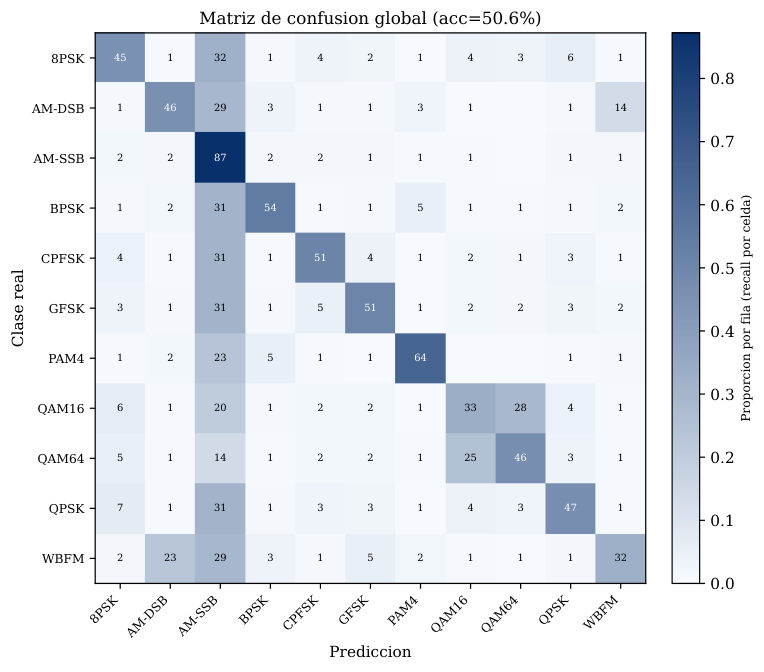

confusion_grid_snr.pdf


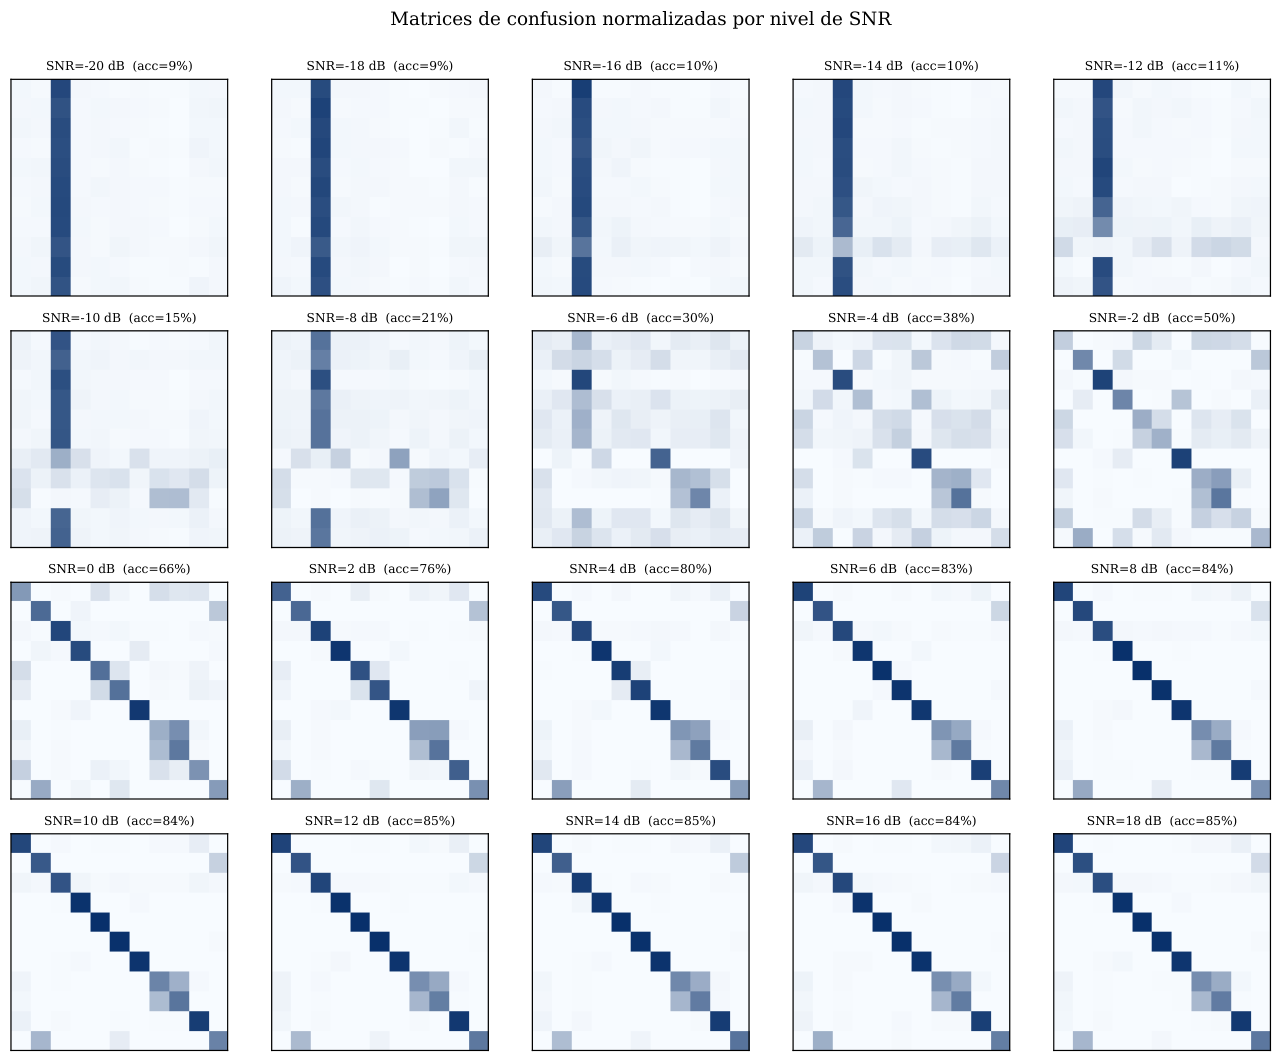

metricas_por_clase.pdf


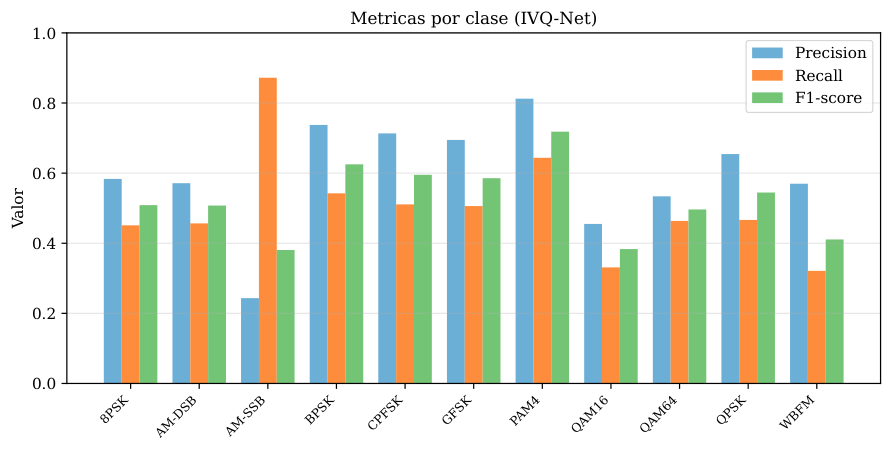

f1_vs_snr.pdf


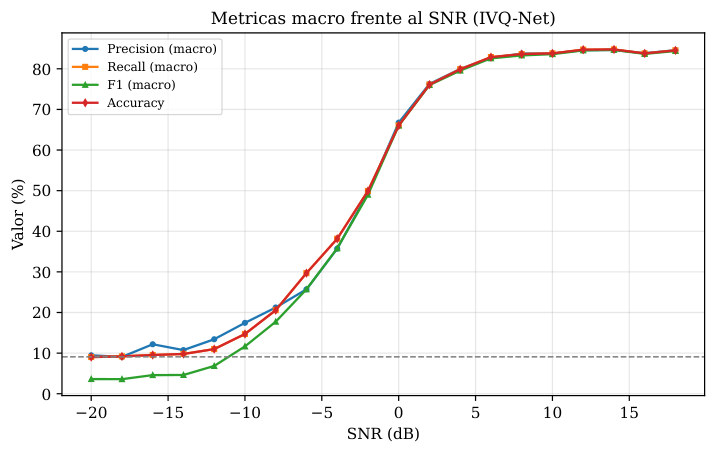

XGBoost
accuracy_vs_snr.pdf


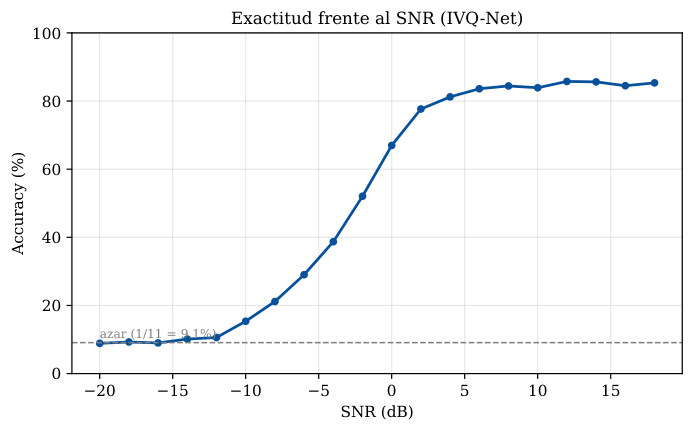

confusion_global.pdf


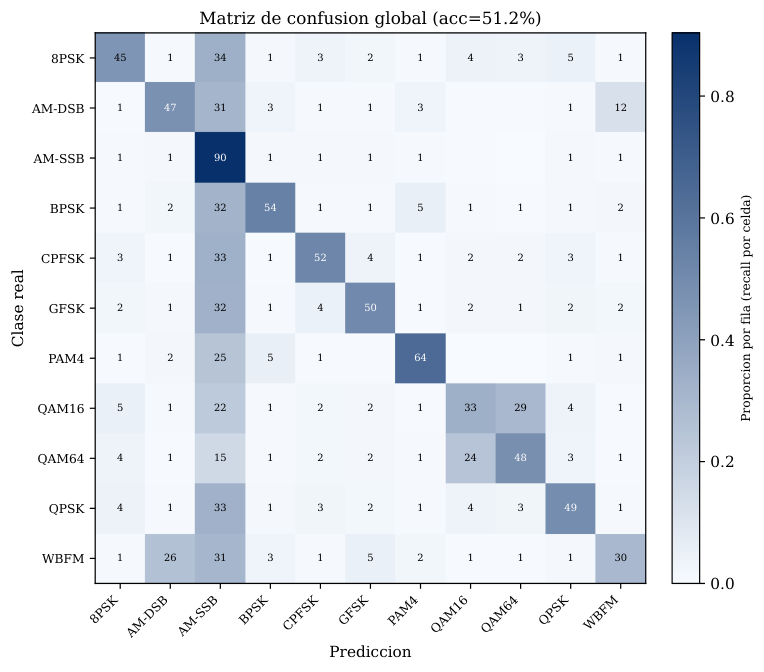

confusion_grid_snr.pdf


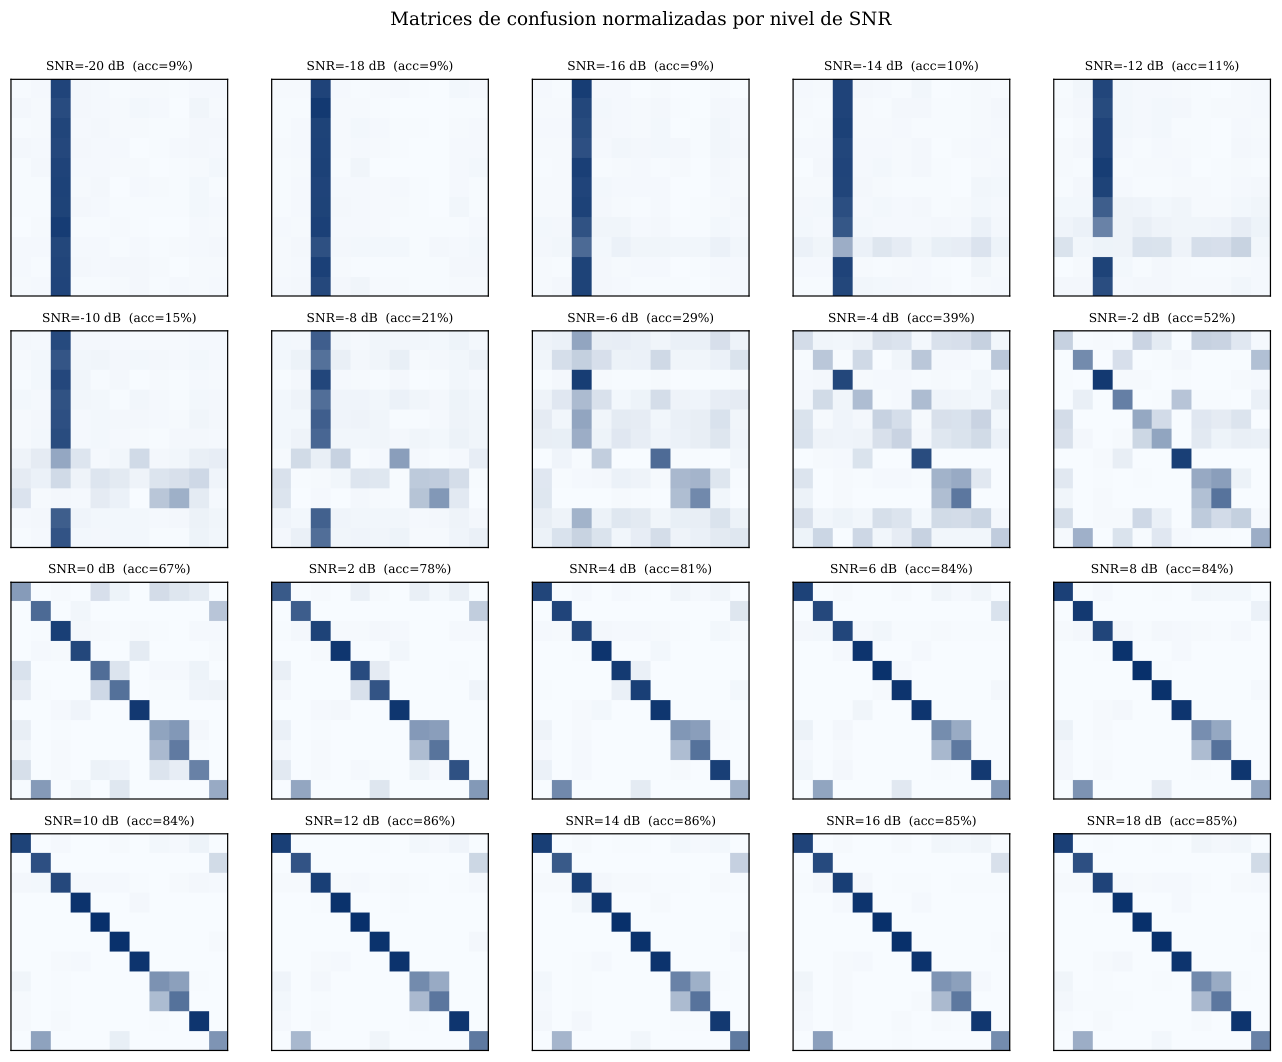

metricas_por_clase.pdf


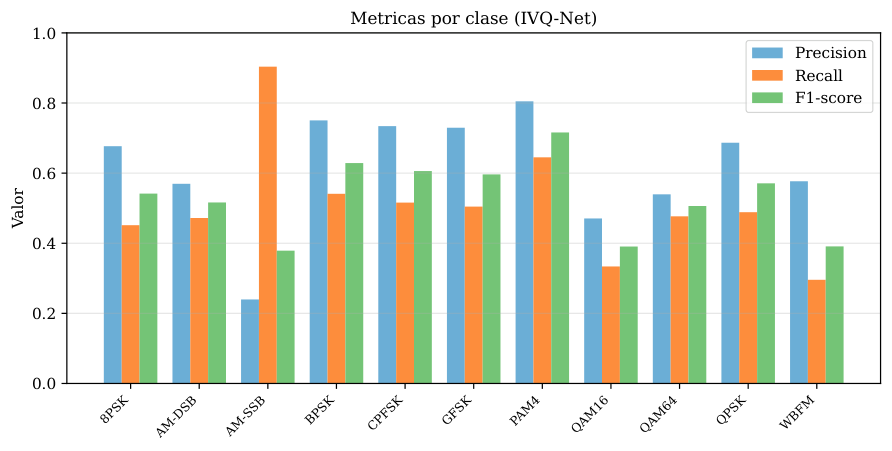

f1_vs_snr.pdf


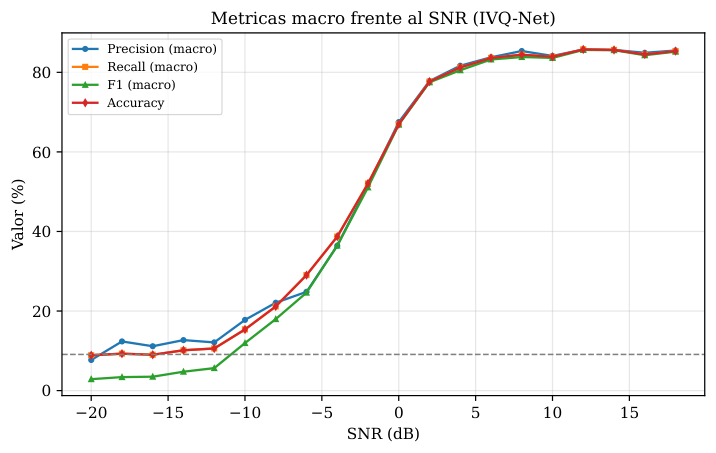

In [ ]:
import fitz                      # PyMuPDF
from IPython.display import Image, display

PRINCIPALES = ['accuracy_vs_snr.pdf', 'confusion_global.pdf',
               'confusion_grid_snr.pdf', 'metricas_por_clase.pdf',
               'f1_vs_snr.pdf', 'curva_error_por_epoca.pdf']

for key, nombre in MODELOS.items():
    pdir = pdf_dirs[key]
    print("=" * 70); print(nombre); print("=" * 70)
    for fn in PRINCIPALES:
        fp = os.path.join(pdir, fn)
        if not os.path.exists(fp):
            continue
        doc = fitz.open(fp)
        pix = doc[0].get_pixmap(dpi=110)
        print(fn)
        display(Image(data=pix.tobytes('png')))
        doc.close()

## 13. (Opcional) Diagnóstico rápido de separabilidad de features

En el espíritu de tu `diagnostico_features.py`: un clasificador trivial (centroide más cercano) sobre las 16
features escaladas, como cota barata de cuánto separan las clases **antes** de cualquier modelo. Si esto ya da
muy por encima del azar (1/11 ≈ 9.1 %), las features sirven y el rendimiento depende del modelo/hiperparámetros.

In [ ]:
def nearest_centroid(Xtr, ytr, Xte):
    cls = np.unique(ytr)
    cents = np.array([Xtr[ytr == c].mean(0) for c in cls])
    d = np.linalg.norm(Xte[:, None, :] - cents[None, :, :], axis=2)
    return cls[d.argmin(1)]

if TRAINED:
    _Xtr = Xtr
else:
    _Xtr = scaler.transform(X_feat[idx_tr])   # solo para el diagnóstico
pred_nc = nearest_centroid(_Xtr, ytr, Xte)
acc_nc = (pred_nc == yte).mean() * 100
print(f"Azar (1/{len(classes)}) = {100/len(classes):.2f}%")
print(f"Centroide más cercano (16 features) = {acc_nc:.2f}%")
print(">>> Las features separan." if acc_nc > 100/len(classes) + 3
      else ">>> Cercano al azar: revisar features.")

Azar (1/11) = 9.09%
Centroide más cercano (16 features) = 33.15%
>>> Las features separan.


---
Listo. Cada modelo tiene su juego completo de CSVs y figuras PDF con tu estética, reproducibles y sin reentrenar
si ya existían los modelos. Para la tesis: las figuras de `svm/`, `rf/` y `xgboost/` comparten formato, por lo que
se pueden colocar lado a lado en el capítulo del Objetivo 2.